In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay
import time
import warnings
from sklearn.model_selection import train_test_split,RandomizedSearchCV,StratifiedKFold,learning_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, f1_score, auc,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve)
import xgboost as xgb
from xgboost import XGBClassifier
 #fix all randomness for full reproducibility
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

In [2]:
# Load the data 

In [3]:
raw = pd.read_csv('Churn_Modelling.csv')
# source:https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/data
raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Preprocessing

In [4]:
# Investigate all the elements within each feature 
for column in raw:
    unique_vals = np.unique(raw[column].fillna('0'))
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature{}:{} -- {}'.format(column,nr_values,unique_vals))
    else:
        print('The number of values for feature{}:{}'.format(column,nr_values))

The number of values for featureRowNumber:10000
The number of values for featureCustomerId:10000
The number of values for featureSurname:2932
The number of values for featureCreditScore:460
The number of values for featureGeography:3 -- ['France' 'Germany' 'Spain']
The number of values for featureGender:2 -- ['Female' 'Male']
The number of values for featureAge:70
The number of values for featureTenure:11 -- [ 0  1  2  3  4  5  6  7  8  9 10]
The number of values for featureBalance:6382
The number of values for featureNumOfProducts:4 -- [1 2 3 4]
The number of values for featureHasCrCard:2 -- [0 1]
The number of values for featureIsActiveMember:2 -- [0 1]
The number of values for featureEstimatedSalary:9999
The number of values for featureExited:2 -- [0 1]


In [5]:
##check for null values
raw.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

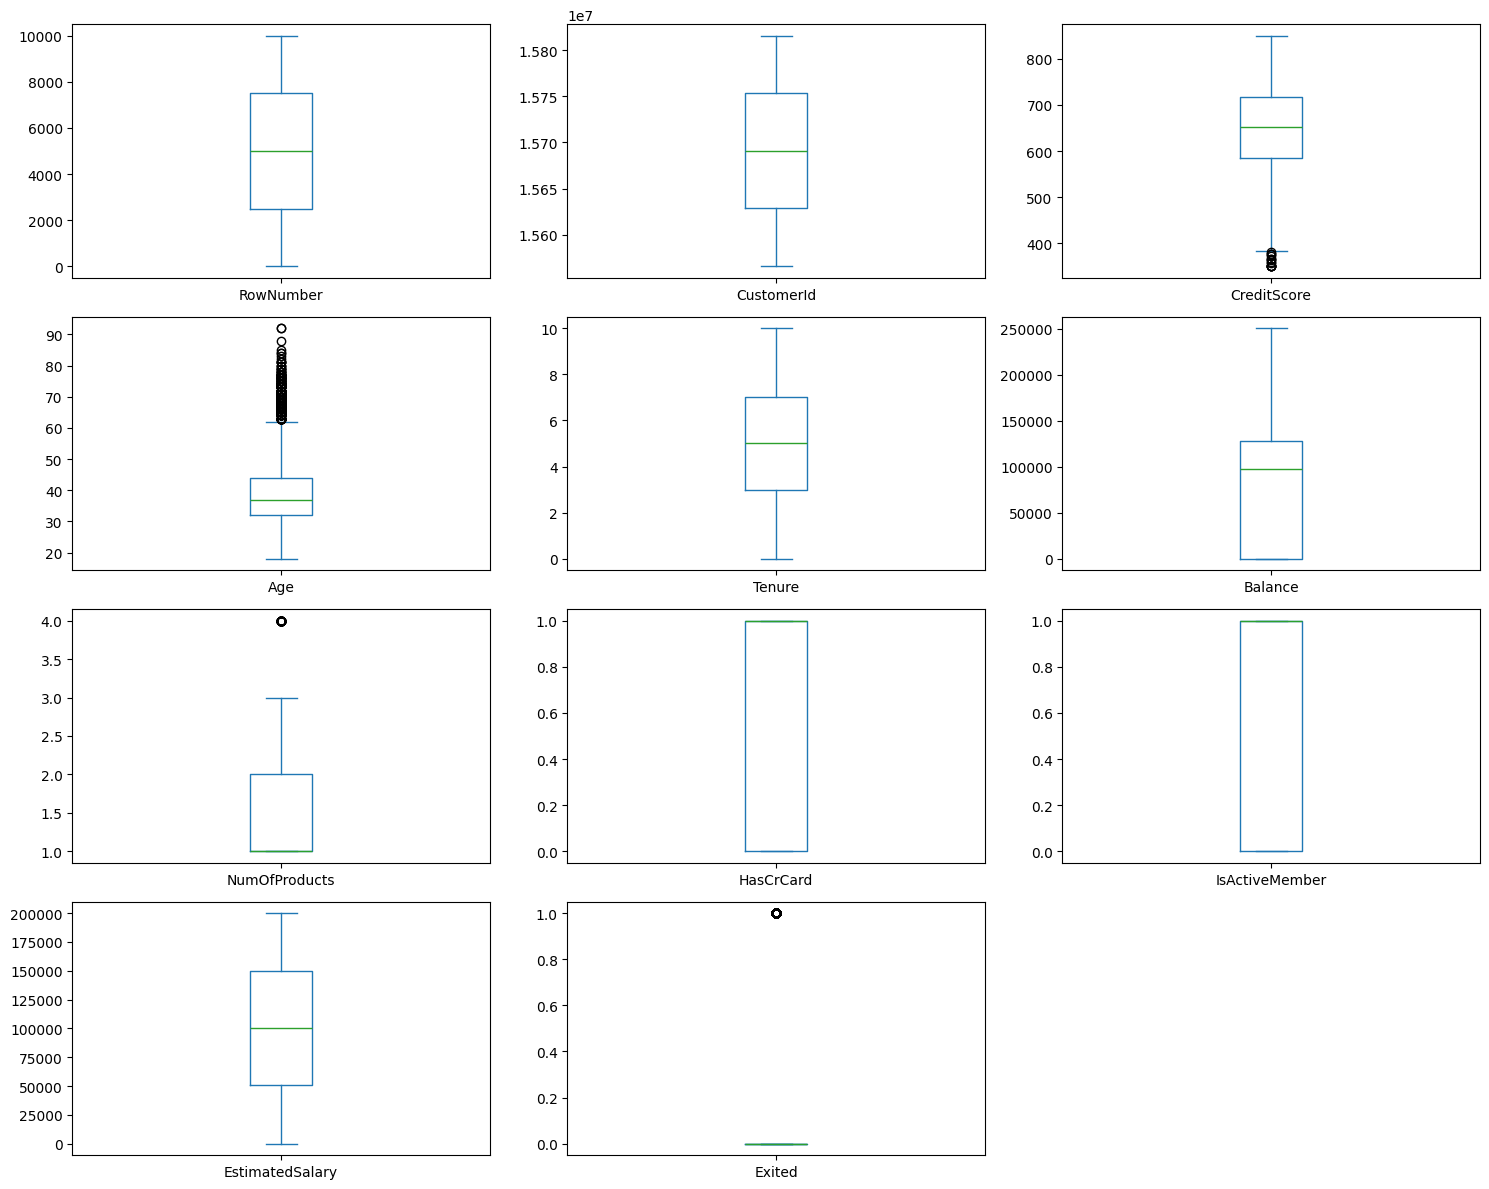

In [6]:

# Select numerical columns
numeric_raw = raw.select_dtypes(include=['number'])

# Create separate boxplots
numeric_raw.plot(
    kind='box',
    subplots=True,
    layout=(len(numeric_raw.columns)//3 + 1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

## Visualize our data

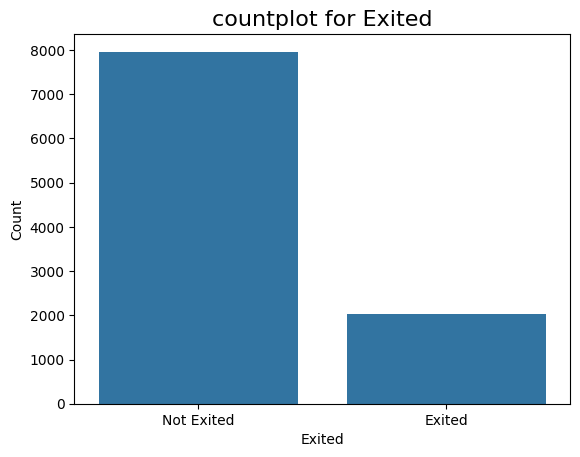

In [7]:
plt.figure()
sns.countplot(raw,x = 'Exited')
plt.title("countplot for Exited",fontsize = 16)
plt.xlabel("Exited")
plt.ylabel('Count')
plt.xticks([0,1],labels = ['Not Exited','Exited'])
plt.show()

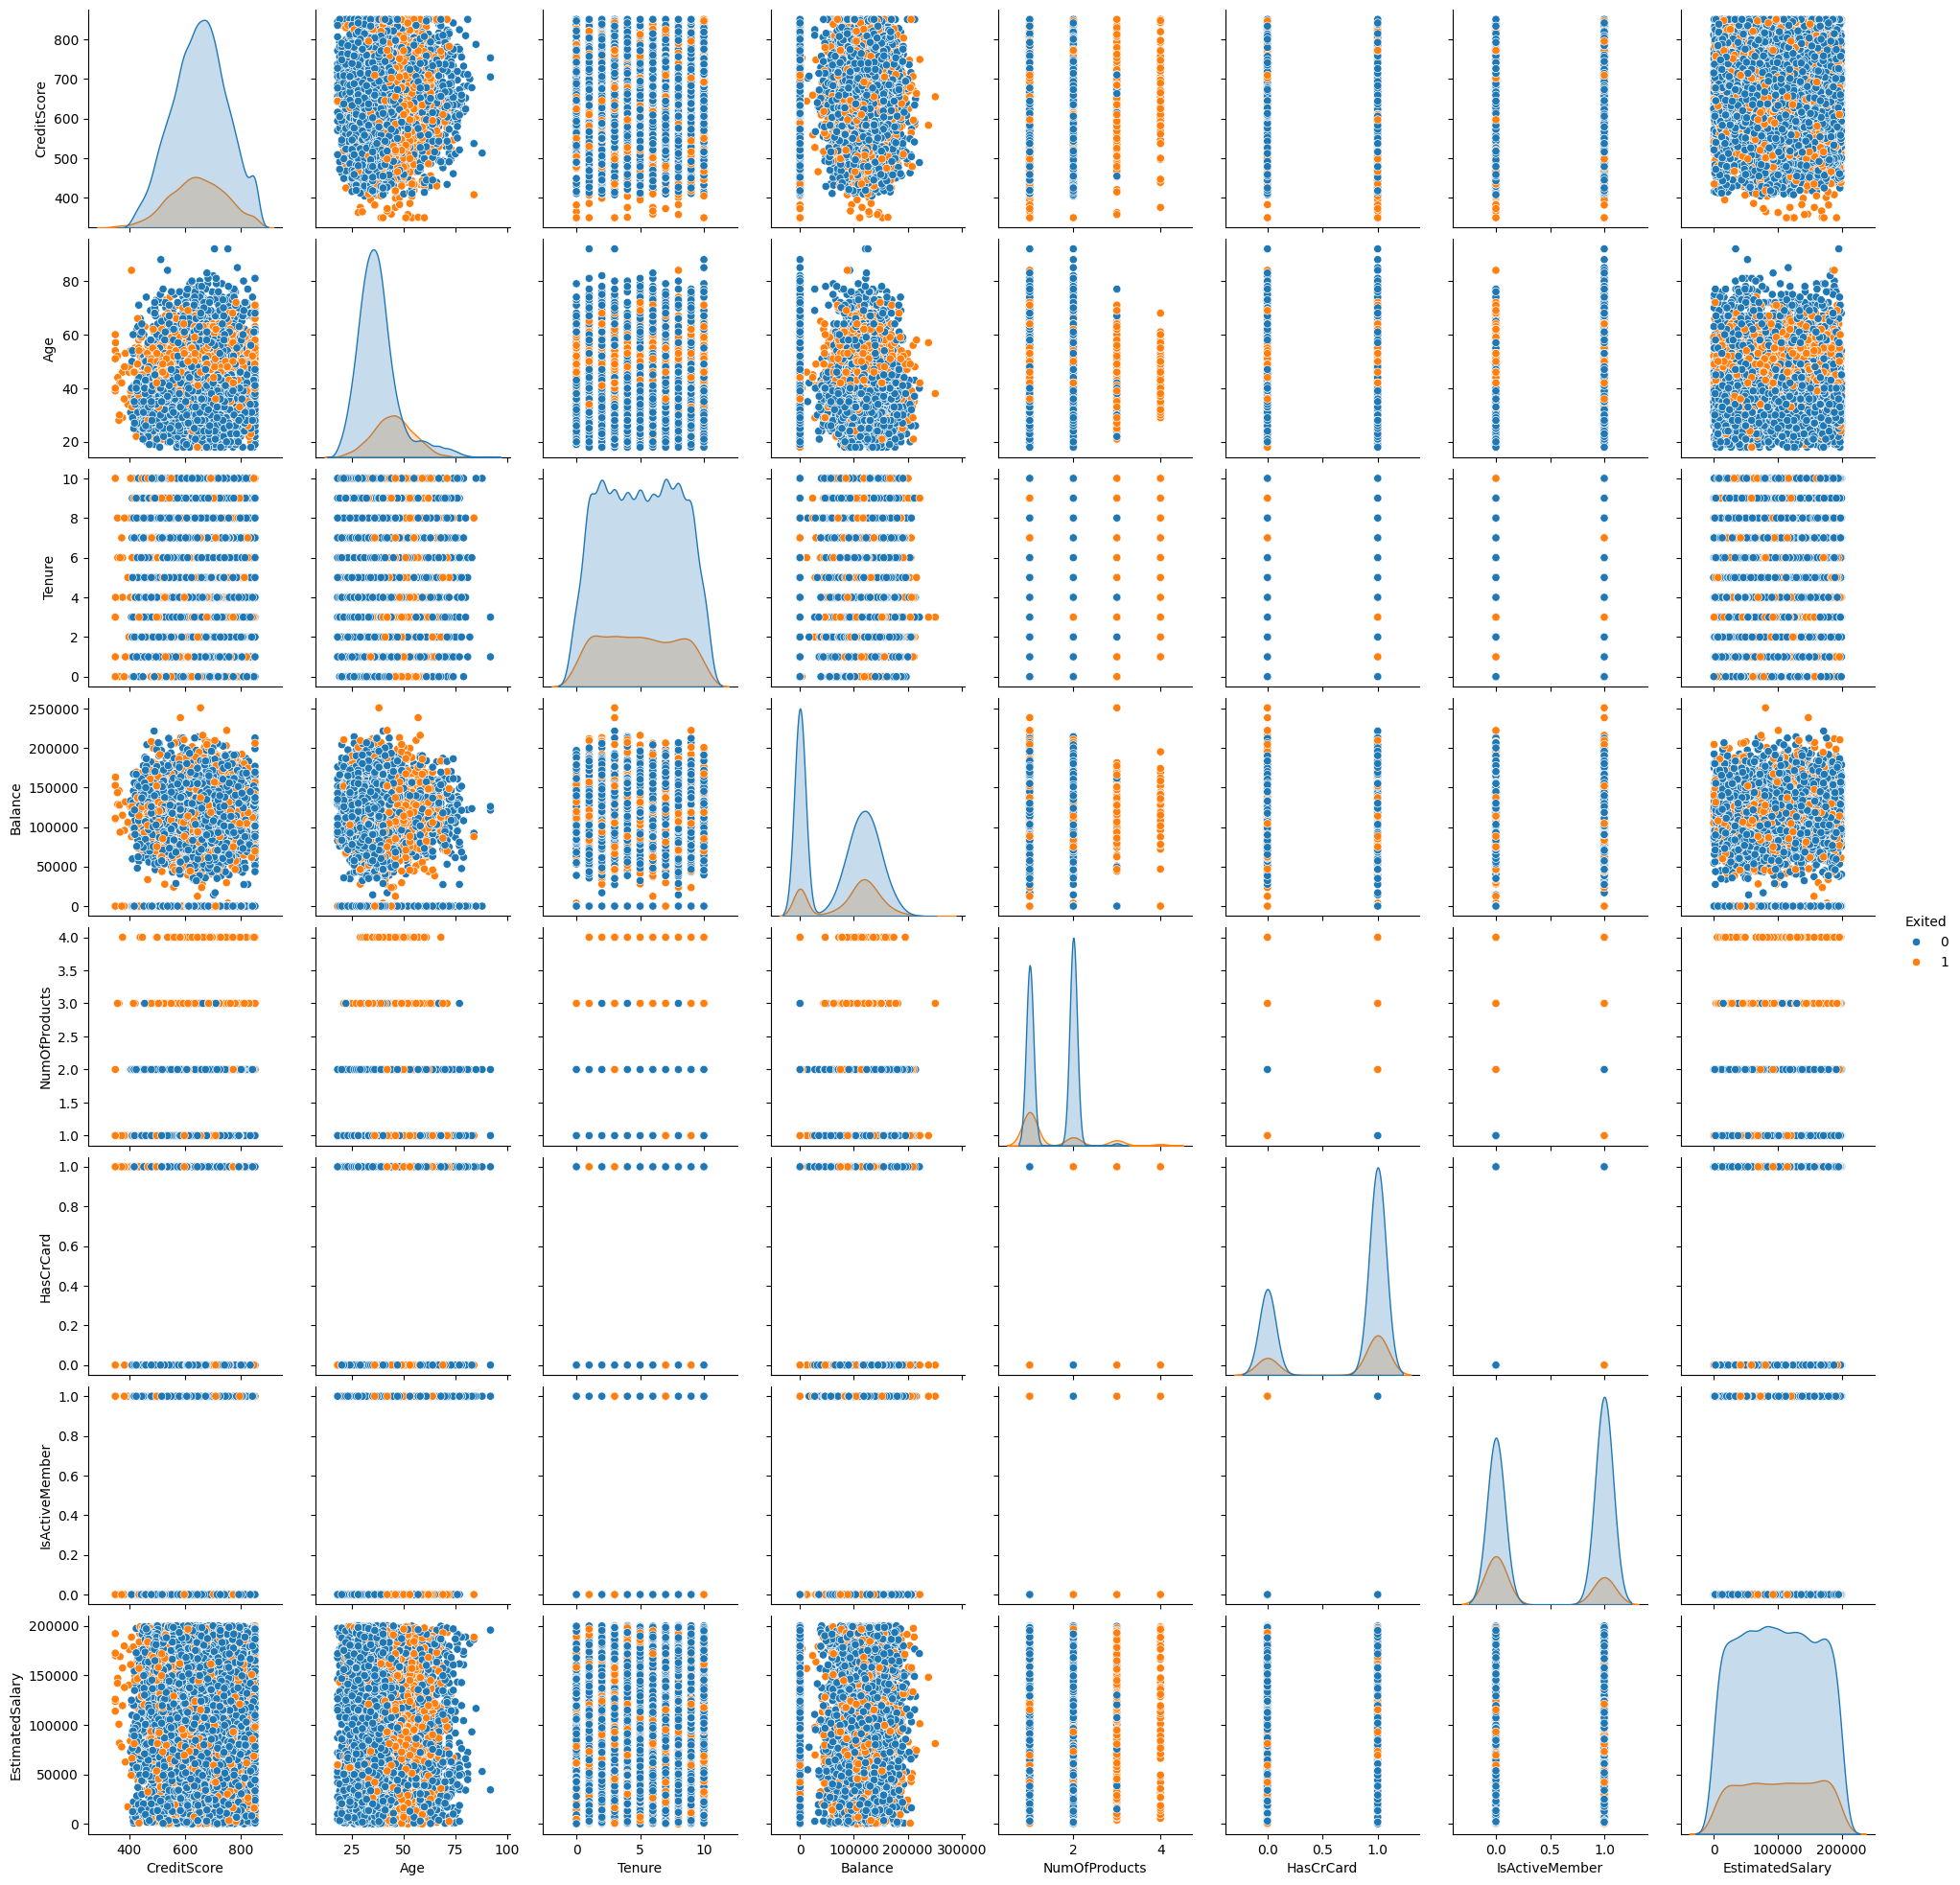

In [8]:
# Limiting the Data
raw_l = raw[['CreditScore','Geography','Gender',
             'Age','Tenure','Balance',
             'NumOfProducts','HasCrCard',
             'IsActiveMember','EstimatedSalary','Exited']]
#Visualizing
g = sns.pairplot(raw_l,hue = 'Exited')

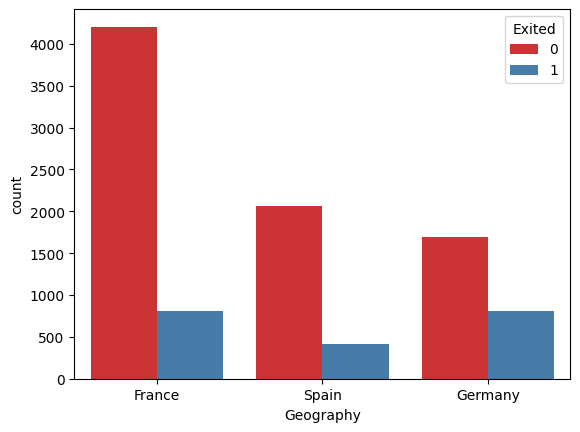

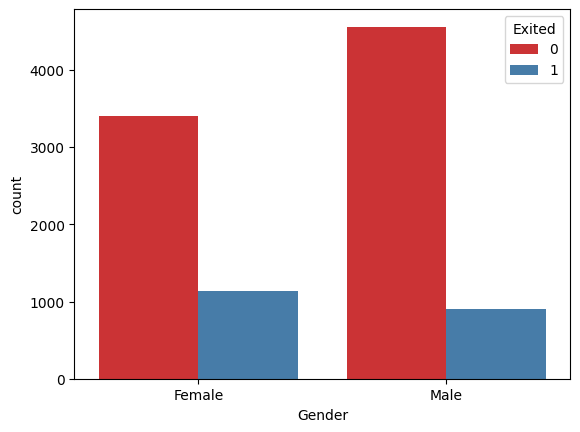

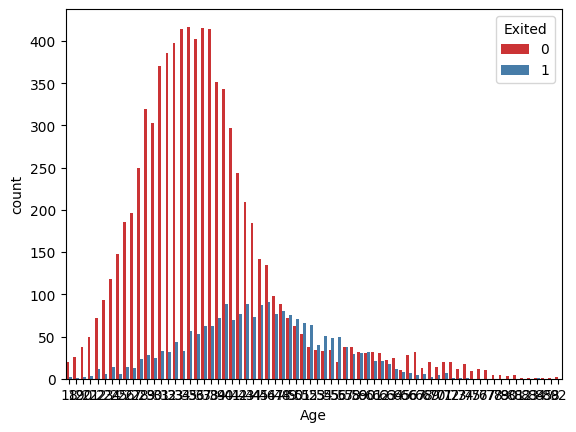

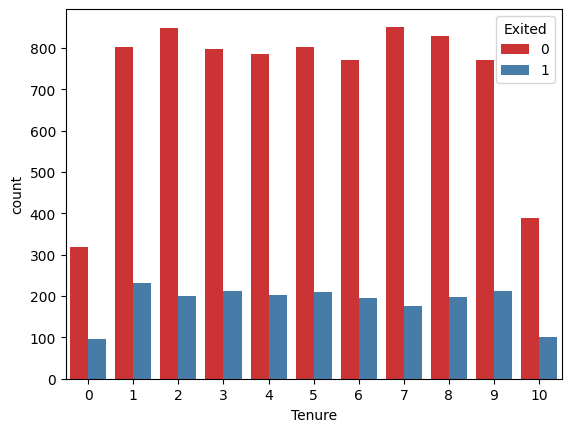

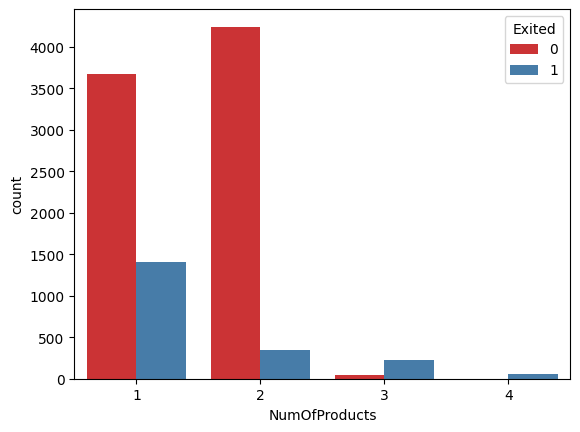

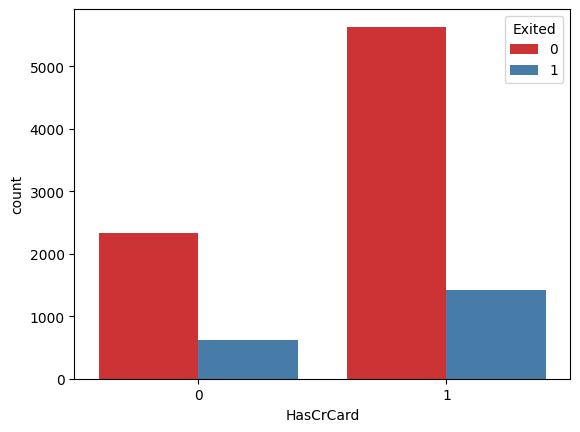

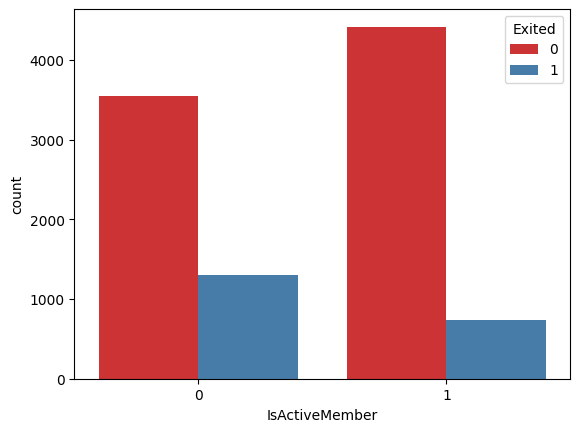

In [9]:
# Investigate all the features by our y
features = ['Geography','Gender',
             'Age','Tenure','NumOfProducts','HasCrCard','IsActiveMember']
for f in features:
    plt.figure()
    ax = sns.countplot(x=f,data=raw_l,hue = 'Exited',palette = 'Set1')

The Median is: 652.0


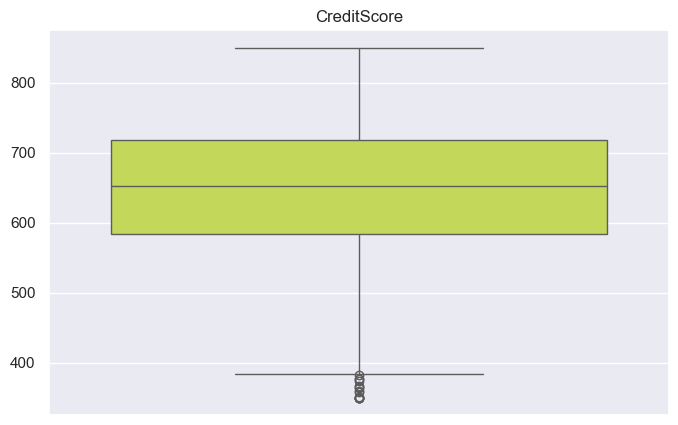

The Median is: 37.0


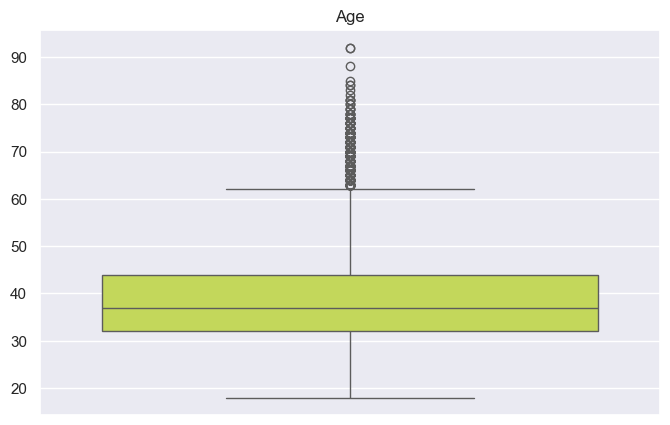

The Median is: 5.0


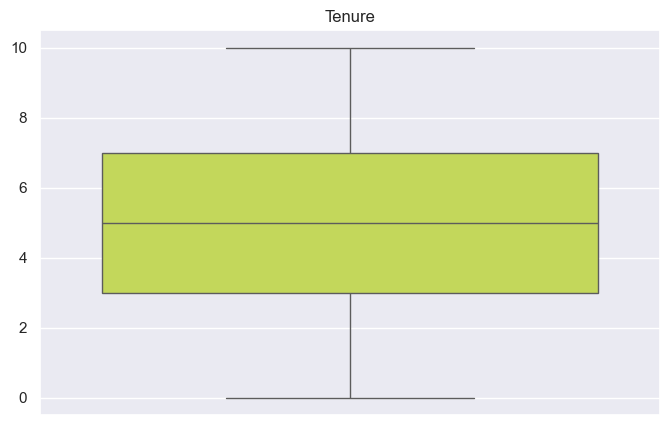

The Median is: 97198.54000000001


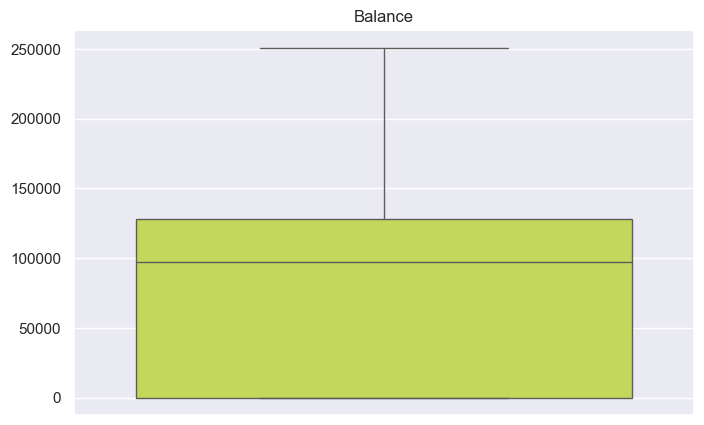

The Median is: 1.0


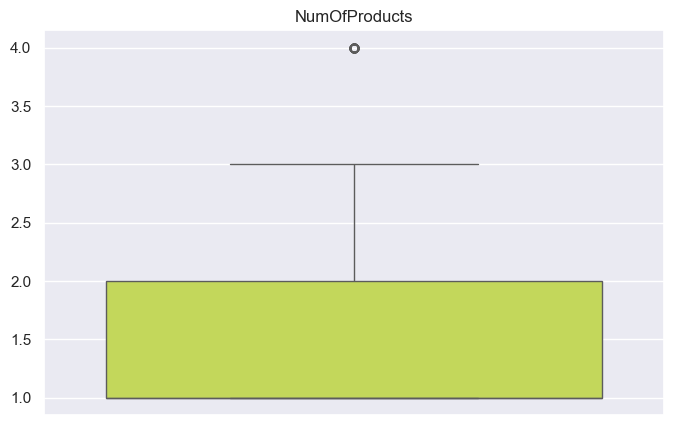

The Median is: 1.0


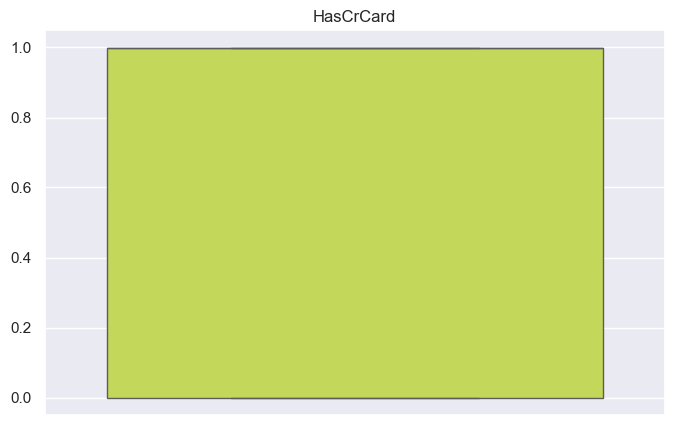

The Median is: 1.0


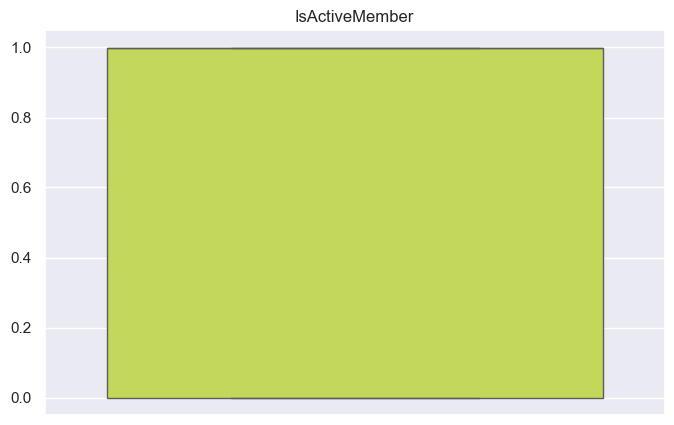

The Median is: 100193.915


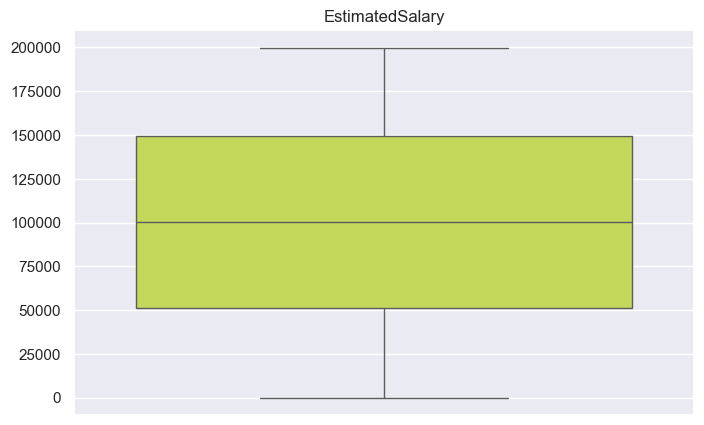

The Median is: 0.0


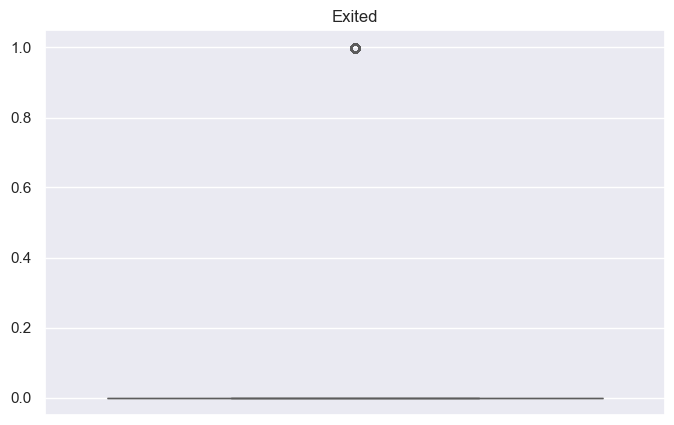

In [10]:
#investigating the distribution of all numeric variables
numerics = ['int16','int32','int64','float16','float32','float64']
n_variables = raw_l.select_dtypes(include=numerics).columns

sns.set(rc = {'figure.figsize':(8,5)})

for c in n_variables:
    x = raw_l[c].values
    ax= sns.boxplot(x, color = '#D1EC46')
    print('The Median is:',raw_l[c].median())
    plt.title(c)
    plt.show()


# Preparing final Df


In [11]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler  # Import MinMaxScaler from scikit-learn

new_raw = pd.get_dummies(raw_l,columns = ['Geography','Gender','HasCrCard','IsActiveMember'])
#Scaling our columns
scale_vars = ['CreditScore','EstimatedSalary','Tenure','Balance','NumOfProducts']
scaler = MinMaxScaler() 
new_raw[scale_vars] = scaler.fit_transform(new_raw[scale_vars])
new_raw.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,0.538,42,0.2,0.000000,0.000000,0.506735,1,True,False,False,True,False,False,True,False,True
1,0.516,41,0.1,0.334031,0.000000,0.562709,0,False,False,True,True,False,True,False,False,True
2,0.304,42,0.8,0.636357,0.666667,0.569654,1,True,False,False,True,False,False,True,True,False
3,0.698,39,0.1,0.000000,0.333333,0.469120,0,True,False,False,True,False,True,False,True,False
4,1.000,43,0.2,0.500246,0.000000,0.395400,0,False,False,True,True,False,False,True,False,True


# Running XGBoost

Training accuracy:0.958750
Test accuracy:0.858000


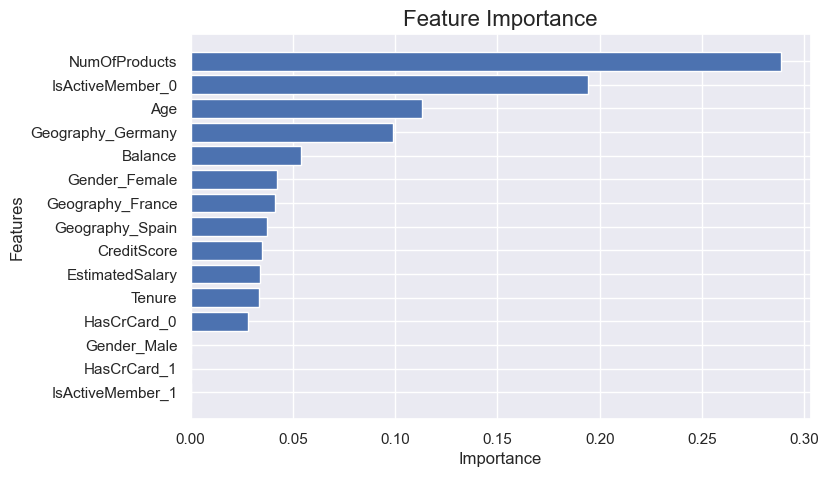


Feature Importance:


,Feature,Importance
4,NumOfProducts,0.288658
13,IsActiveMember_0,0.194039
1,Age,0.113240
7,Geography_Germany,0.099048
3,Balance,0.053883
9,Gender_Female,0.042302
6,Geography_France,0.041067
8,Geography_Spain,0.037478
0,CreditScore,0.034965
5,EstimatedSalary,0.033707


In [12]:
#features(x) and target(y)
X = new_raw.drop(columns = ['Exited'])
y = new_raw['Exited']

#Splitting the data into training  and test set
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

#Initialize the XGBoost classifire
model = XGBClassifier(use_label_encoder=False,eval_metrics='logloss',random_state=42)
model.fit(X_train,y_train)

#predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Training and Testing accuracy
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)

print(f'Training accuracy:{train_accuracy:2f}')
print(f'Test accuracy:{test_accuracy:2f}')

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':model.feature_importances_
}).sort_values(by='Importance',ascending=False)

plt.figure()
plt.barh(feature_importance['Feature'],feature_importance['Importance'],align = 'center')
plt.title("Feature Importance",fontsize = 16)
plt.xlabel("Importance")
plt.ylabel('Features')
plt.gca().invert_yaxis()  # for better readability
plt.show()

print('\nFeature Importance:')
feature_importance


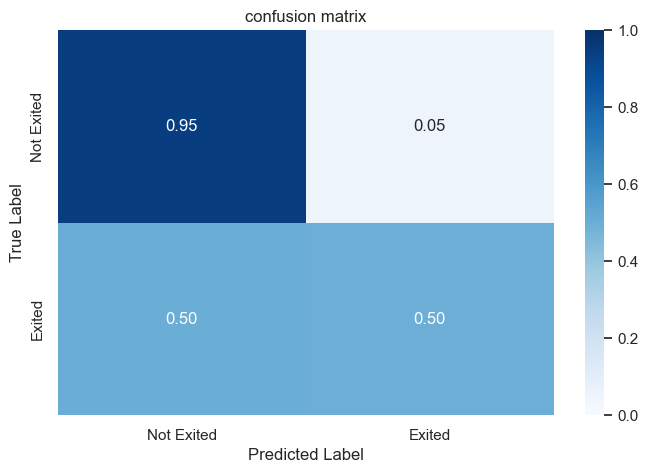

In [13]:
#confusion matrix
def plot_confusion_matrix(cm,classes=None,title = 'confusion matrix'):
    '''Plots an confusion matrix'''
    plt.figure()
    sns.heatmap(cm,xticklabels=classes,yticklabels=classes,vmin=0,vmax=1,annot=True,cmap='Blues',fmt='.2f')
    plt.title(title),
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
# Calculate the confusion matrix
cm = confusion_matrix(y_test,y_test_pred,normalize='true')
plot_confusion_matrix(cm,classes=['Not Exited','Exited'])    

In [14]:
#!pip uninstall imbalanced-learn -y
#!pip uninstall scikit-learn -y

In [15]:
#!pip install scikit-learn==1.5.2
#!pip install imbalanced-learn==0.12.4

In [16]:
# Rerun XGBoost with smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)


In [17]:
print("\nAfter SMOTE:")
print(y_train_res.value_counts())


After SMOTE:
Exited
0    6356
1    6356
Name: count, dtype: int64


Training accuracy:0.966410
Test accuracy:0.859500


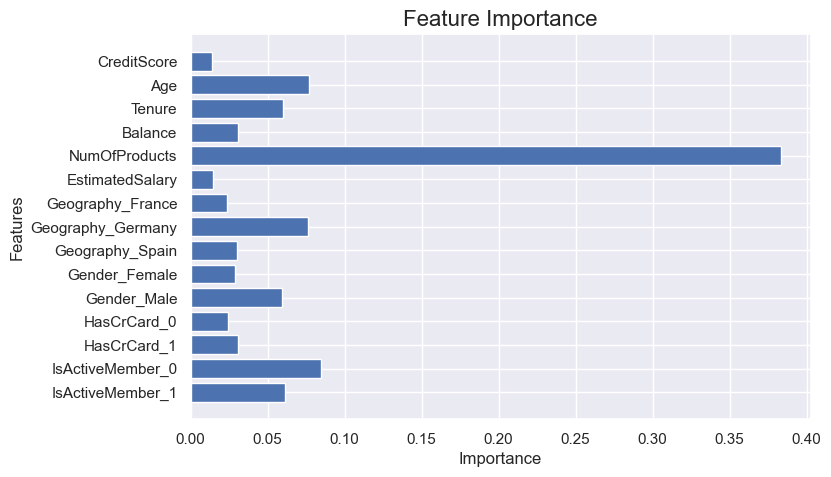

In [18]:
#Initialize the XGBoost classifire
model = XGBClassifier(use_label_encoder=False,eval_metrics='logloss',random_state=42)
model.fit(X_train_res,y_train_res)

#predictions
y_train_pred = model.predict(X_train_res)
y_test_pred = model.predict(X_test)

#Training and Testing accuracy
train_accuracy = accuracy_score(y_train_res,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)

print(f'Training accuracy:{train_accuracy:2f}')
print(f'Test accuracy:{test_accuracy:2f}')

feature_importance=model.feature_importances_
plt.figure()
plt.barh(X_train.columns,feature_importance,align = 'center')
plt.title("Feature Importance",fontsize = 16)
plt.xlabel("Importance")
plt.ylabel('Features')
plt.gca().invert_yaxis()  # for better readability
plt.show()



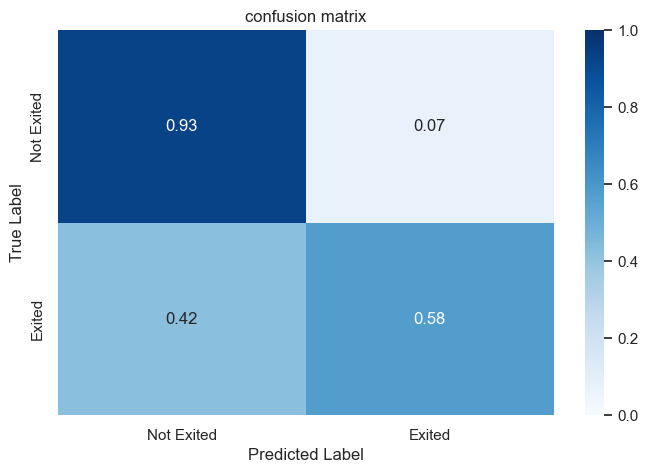

In [19]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test,y_test_pred,normalize='true')
plot_confusion_matrix(cm,classes=['Not Exited','Exited'])  

Training Accuracy: 0.82
Testing Accuracy: 0.81


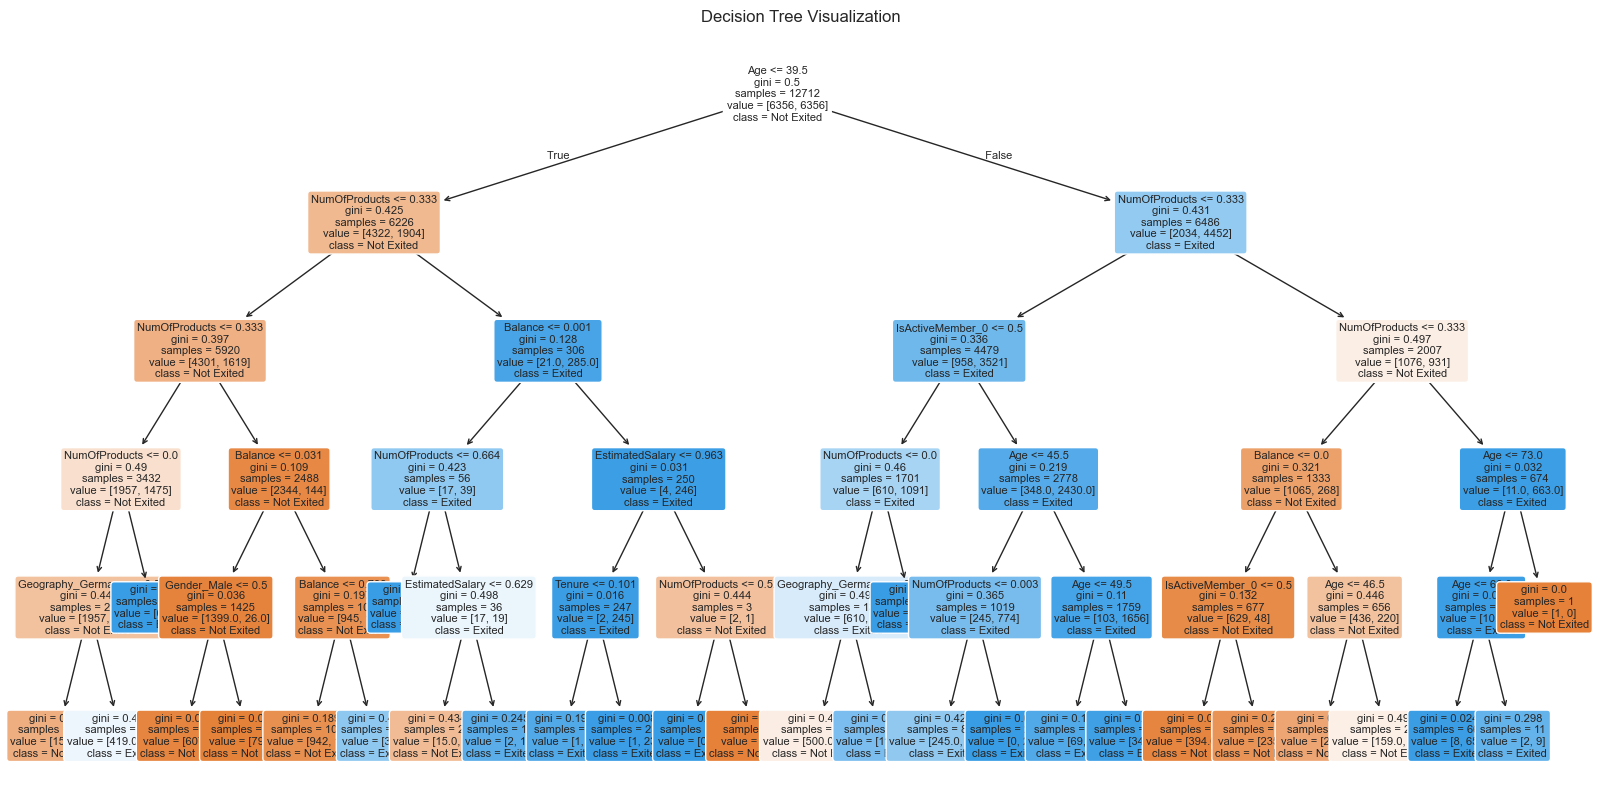

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the model
dt = DecisionTreeClassifier(
    max_depth=5,           # adjust as needed
    random_state=42
)

# Train the model
dt.fit(X_train_res, y_train_res)

# Predictions
y_train_pred = dt.predict(X_train_res)
y_test_pred = dt.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['Not Exited', 'Exited'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

## Hyperparameter Tuning

In [21]:
from sklearn.model_selection import RandomizedSearchCV
# define the parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators":[100,200,300],      # no of trees
    "max_depth":[3,5,7,10],            # max depth of trees
    "learning_rate":[0.01,0.05,0.1,0.2], # step size shrinkage (fixed: removed space)
    "subsample":[0.6,0.8,1.0],          #fractions of samples to grow trees
    "colsample_bytree":[0.6,0.8,1.0],   # fractions of features for tree building
    "gamma":[0,1,5],                    # minimum loss reduction for split
    "reg_lambda":[1,10,50]              # l2 regularization term
}

# initialize the XGBoost classifier
xgb_base = XGBClassifier(use_label_encoder=False,eval_metric="logloss",random_state=42)

# apply Randomized search
random_search = RandomizedSearchCV(
    estimator = xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # no of parameter setting sampled
    scoring = "f1",
    cv = 5,    # 5 fold cv
    random_state = 42,
    verbose = 1,
    n_jobs = -1  # use all available cores
)
# fit the RandomizedSearchCV
random_search.fit(X_train_res,y_train_res)

# get the best parameters and model
best_params = random_search.best_params_
# Fixed: get the actual best estimator instead of just parameters
best_model = random_search.best_estimator_

#predictions
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test)
all_df_predict = best_model.predict(X)
all_df_predict_prob = best_model.predict_proba(X)

#Training and Testing accuracy
train_accuracy = accuracy_score(y_train_res,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)

print(f'Training accuracy:{train_accuracy:.2f}')  # Fixed: added missing colon in format
print(f'Test accuracy:{test_accuracy:.2f}')       # Fixed: added missing colon in format

# feature Importance
feature_importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":best_model.feature_importances_  # Fixed: added 's' to feature_importances_
}).sort_values(by='Importance',ascending=False)
feature_importance

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Training accuracy:0.95
Test accuracy:0.86


,Feature,Importance
4,NumOfProducts,0.525952
13,IsActiveMember_0,0.084235
14,IsActiveMember_1,0.080112
1,Age,0.059051
7,Geography_Germany,0.050094
2,Tenure,0.038437
3,Balance,0.028302
10,Gender_Male,0.026447
9,Gender_Female,0.025202
8,Geography_Spain,0.020449


In [22]:
raw['Exited prediction']=all_df_predict
raw['Exited probability prediction']=all_df_predict_prob[:,1]
raw.to_excel("bank_churn_data.xlsx")

In [23]:
feature_importance['feature importance score']=feature_importance["Importance"].round(4)
feature_importance.to_excel("feature_importance.xlsx")

# Save Model

In [26]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------------------------------------------------
# 1. Load the trained best model from RandomizedSearchCV
# -----------------------------------------------------------------------------
# Note: Ensure you have run the cell with 'random_search.fit(...)' in your notebook
# and that the variable 'random_search' exists in your kernel.
try:
    # If you are running this as a separate script, you might need to load the model 
    # if it was already saved, or ensure 'random_search' is in memory.
    # Assuming 'random_search' is available from the previous notebook execution context:
    
    # If you haven't saved it yet, uncomment the next line if running in the same notebook session:
    # best_model = random_search.best_estimator_ 
    
    # For this script, let's assume we are saving the objects directly from the notebook variables.
    # If you are running this as a standalone .py file, you need to load the model first.
    # For now, I will write the code assuming the variables exist in the current scope.
    
    # IMPORTANT: Replace these lines with actual loading if running as a separate script
    # e.g., with open('best_model.pkl', 'rb') as f: best_model = pickle.load(f)
    
    # Let's assume these variables are available from your notebook execution
    # If you are copying this into a new cell in the notebook:
    try:
        best_model = random_search.best_estimator_
    except NameError:
        raise Exception("Variable 'random_search' not found. Please run the Hyperparameter Tuning cell in your notebook first.")

    # -----------------------------------------------------------------------------
    # 2. Define the exact features used during training
    # -----------------------------------------------------------------------------
    # These MUST match the columns of X_train after get_dummies and scaling
    feature_names = [
        "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary",
        "Geography_France", "Geography_Germany", "Geography_Spain",
        "Gender_Female", "Gender_Male",
        "HasCrCard_0", "HasCrCard_1",
        "IsActiveMember_0", "IsActiveMember_1"
    ]

    # Columns that were scaled in the notebook
    scale_vars = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

    # -----------------------------------------------------------------------------
    # 3. Fit the Scaler
    # -----------------------------------------------------------------------------
    # We need to fit the scaler on the same data structure the model was trained on.
    # Since we don't have X_train_res here easily without reloading, 
    # we will create a dummy dataframe to fit the scaler if we don't have the original scaler.
    # HOWEVER, it is BEST PRACTICE to save the scaler that was ALREADY FITTED on the training data.
    
    # If you have the 'scaler' object from your notebook (where you did scaler.fit_transform), use it:
    try:
        # Assuming 'scaler' is the fitted scaler from your notebook
        scaler_obj = scaler 
    except NameError:
        raise Exception("Variable 'scaler' not found. Please ensure the scaler is fitted and available in the namespace.")

    # -----------------------------------------------------------------------------
    # 4. Save the Model and Scaler
    # -----------------------------------------------------------------------------
    
    # Save the best model
    with open("best_model.pkl", "wb") as file:
        pickle.dump(best_model, file)
    print("✅ Model saved as 'best_model.pkl'")

    # Save the scaler
    with open("scaler.pkl", "wb") as file:
        pickle.dump(scaler_obj, file)
    print("✅ Scaler saved as 'scaler.pkl'")

    # -----------------------------------------------------------------------------
    # 5. Save Feature Importance for the App
    # -----------------------------------------------------------------------------
    # Extract feature importance from the best model
    importances = best_model.feature_importances_
    
    # Create a DataFrame for the app to read
    feat_imp_df = pd.DataFrame({
        "feature": feature_names,
        "Feature Importance Score": importances
    })
    
    # Sort by importance for better visualization in the app
    feat_imp_df = feat_imp_df.sort_values(by="Feature Importance Score", ascending=False)
    
    # Save to Excel
    feat_imp_df.to_excel("feature_importance.xlsx", index=False)
    print("✅ Feature importance saved as 'feature_importance.xlsx'")

    print("\n🎉 All files saved successfully! You can now run app.py")

except Exception as e:
    print(f"❌ Error saving models: {e}")
    print("Please ensure you have run all previous cells in the notebook, especially the Hyperparameter Tuning section.")

✅ Model saved as 'best_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Feature importance saved as 'feature_importance.xlsx'

🎉 All files saved successfully! You can now run app.py
